# Машинное обучение, ФКН ВШЭ

## Практическое задание 2. Градиентный спуск своими руками




### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных модификаций градиентного спуска. В файле `descents.py` вам нужно будет реализовать несколько классов для различных вариаций градиентного спуска, а именно:
* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`


В файле `linear_regression.py` вам необходимо будет реализовать класс `CustomLinearRegression` для обучения линейной регрессии (и, разумеется, предсказания целевой переменной на основе обученной модели).


### Про предложенную архитектуру

Предложенная вам архитектура шаблонов написана по принципам SOLID: основная ее идея в том, что вы сможете использовать различные лоссы и оптимизаторы с одним и тем же кодом прочих классов, никак не изменяя и не переписывая методы классов, которые с оптимизаторами и лоссом взаимодействуют. Мы добиваемся этого при помощи выделения интерфейсов (в Python мы достигаем этого при помощи абстрактных классов, см дальше в заданиях) и выделения зон ответственности каждого класса.

Глобально в нашей архитектуре всего 4 интерфейса (некоторые из которых на самом деле сразу concrete классы), каждый из которых порождает одно семейство:
- `interfaces.LossFunction`
  - Классы, имплементирующие этот интерфейс, отвечают за одну конкретную функцию потерь, используемую при обучении, и всё, что меняется вместе с ней при её замене: подсчёт лосса, подсчет градиента и аналитическое решение (если есть, то добавляется в интерфейс соответствующим mixin-ом).
- `interfaces.LinearRegressionInterface`
  - Интерфейс обертки для модели линейной регрессии, контейнер, содержащий составные части (лосс-функцию и оптимизатор) и использующий их для выполнения содержательной работы.
- `interfaces.LearningRateSchedule`
 - Простенькое семейство расписаний, определяющих шаг обучения для каждой итерации
- `interfaces.AbstractOptimizer`.
  -  Классы, имплементирующие этот интерфейс, имплементируют конкретный алгоритм оптимизации и всё, что происходит в его процессе. Пользуются обёрткой линейной регрессии для доступа к данным и вызова расчетов, чтобы не зависеть напрямую от конкретных функций потерь и шедулеров шага обучения.

Концепция передачи маленьких объектов, отвечающих за свою маленькую зону ответственности внутрь более сложного объекта для выполнения ими составных частей работы называется Dependency Injection, и работает как раз за счет выделения зоны ответственности и опоры на интерфейс вместо реализации.

Посмотрите на код `linear_regression.CustomLinearRegression`: она принимает в себя объекты с интерфейсами `LossFunction` и `AbstractOptimizer`, а в `descents.BaseDescent` как уточнении интерфейса абстрактного оптимизатора до итеративных оптимизаторов видно, что он в свою очередь принимает при инициализации объект шедулера шага обучения.

Благодаря этому, код, который использует эти классы, может по очереди:
- Инициализировать нужный шедулер с нужными параметрами для задания шага обучения
- Иницализировать оптимизатор, задав ему нужные параметры процесса и передав готовый шедулер
- Инициализировать класс линейной регрессии нужной под задачу функцией потерь и уже готовым оптимизатором.
- Запустить процесс обучения

И на любом этапе можно использовать другой объект с подходящим интерфейсом, и всё будет работать!


**В ходе выполнения этой домашки вы наполните все эти семейства классов различными имплементациями и будете менять их на ходу как перчатки!**

Более подробно про наследование классов в Python можно прочитать здесь:
* Наследование: https://docs.python.org/3/tutorial/classes.html#inheritance
* Абстрактные классы: https://docs.python.org/3/library/abc.html



## Задание 1. Линейная регрессия  (1 балл)

### Градиент функции потерь MSE

На семинаре про [матрично-векторное дифференцирование](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem03-vector-diff.pdf) вы должны были обсуждать дифференцирование функции потерь MSE в матричном виде.

### Задание 1.0. Градиент MSE в матричном виде (0.3 балла).

Напомним, что функция потерь MSE записывается как:

$$
    Q(w) = \frac{1}{\ell} \sum \limits_{i = 1}^\ell (y_i - \langle x_i, w \rangle)^2 = \frac{1}{\ell} \| X w - y \|^2
$$

где $\ell$ – количество объектов в выборке, $X \in \mathbb{R}^{\ell \times d}$ – матрица "объект-признак", а $y \in \mathbb{R}^\ell$ – целевая переменная. Через $x_i$ обозначается $i$-ая строчка матрицы $X$, отвечающая за $i$-й объект выборки.

- **Выпишите ниже (подсмотрев в семинар или решив самостоятельно) градиент для функции потерь MSE в матричном виде.**

**Решение:**

`### your solution here (ಠ.ಠ) ###`
Можно оставить решение как в семинаре - 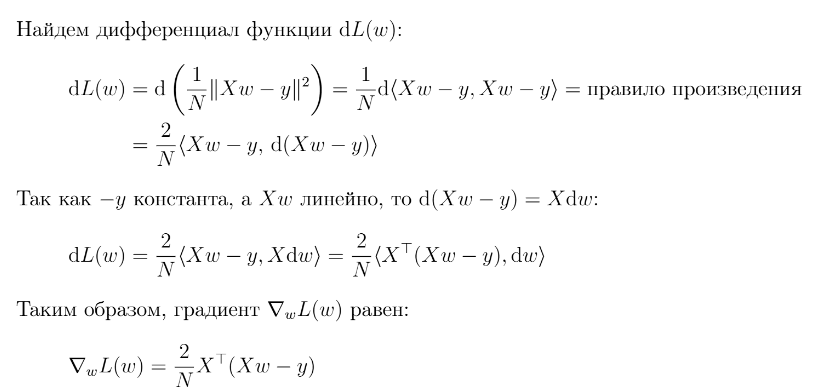

Но это скучно, поэтому напишу свое (вроде тоже верное)

**Решение:**

используя свойство нормы $\|a\|^2 = a^T a$:
$$Q(w) = \frac{1}{\ell} (Xw - y)^T (Xw - y)$$

т.к. $(AB)^T = B^T A^T$:
$$Q(w) = \frac{1}{\ell} (w^T X^T X w - w^T X^T y - y^T X w + y^T y)$$

$y^T X w = (y^T X w)^T = w^T X^T y$ т к
полученный результат все равно будет скаляром

Тогда:
$$Q(w) = \frac{1}{\ell} (w^T X^T X w - 2 w^T X^T y + y^T y)$$

Теперь возьмем градиент по вектору $w$, используя формулы матричного дифференцирования:
1. $\nabla_w (w^T X^T X w) = 2 X^T X w$
2. $\nabla_w (2 w^T X^T y) = 2 X^T y$
3. $\nabla_w (y^T y) = 0$

Собираем результат:
$$\nabla_w Q(w) = \frac{2}{\ell} (X^T X w - X^T y) = \frac{2}{\ell} X^T (Xw - y)$$

**Ответ:**
$$\nabla_w Q(w) = \frac{2}{\ell} X^T (X w - y)$$



- **Имплементируйте методы `MSELoss.loss`, `MSELoss.gradient`**





### Задание 1.1 Аналитическое решение и `CustomLinearRegression` (0.7 балла)

Перед тем, как мы углубимся в итеративные методы оптимизации, давайте вспомним, что для ряда функций потерь существует и аналитическое решение. Давайте сперва вспомним, как оно выглядит для MSE.

- **Выведите формулу оптимальных $w$ в задаче минимизации MSE, и запишите её ниже.**

Для нахождения весов $w$, приравняем градиент функции потерь к нулю:
$$\nabla_w Q(w) = 0$$


$$\frac{2}{\ell} X^T (Xw - y) = 0$$

$$X^T X w - X^T y = 0$$

$$X^T X w = X^T y$$

Предполагая, что матрица $X^T X$ является невырожденной, умножим обе части уравнения слева на $(X^T X)^{-1}$:
$$(X^T X)^{-1} X^T X w = (X^T X)^{-1} X^T y$$

Так как $(X^T X)^{-1} X^T X = I$:
$$w = (X^T X)^{-1} X^T y$$

**Ответ:**
$$w = (X^T X)^{-1} X^T y$$

- **Имплементируйте подсчет этого решения в `MSELoss._plain_analytic_solution`**

$$\text{MSE} = \| X w - y \|^2$$
$$ w = (X^T X)^{-1} X^T y$$

**Вопрос**: Как мы помним, у аналитического решения есть минусы - какие?

**Ответ**: `# your text here (ಠ.ಠ)`

Вычислительная сложность примерно $O(d^3)$ (d - количество признаков) -> если много признаков, то вычисления становятся медленными

Проблемы с вырожденностью - если среди признаков есть линейно зависимые, то ~~все, капут, приплыли, конец, финиш, завершение, титры...~~ обратную матрицу найти невозможно, т к определитель равен 0

Память - надо хранить таблицу большого размера (если много признаков)

Длч многих функций потерь не существует формулы, выводимой аналитическим решением

Придется заново все считать, если добавятся новые данные



Теперь прокинем это решение в наш класс линейной регрессии, чтобы получше разобраться в архитектуре.


- **Допишите класс `descents.AnalyticSolutionOptimizer`**
- **Допишите класс `CustomLinearRegression`**
  - В нем на текущем этапе нужно имплементировать все методы: `fit` и `predict` вам понадобятся прямо сейчас, а `compute_gradients` и `compute_loss` в следующей части.

Помните, про разделение ответственности классов!

За контроль процесса обучения отвечает оптимизатор, а объект линейной регрессии по факту выступает точкой входа, контейнером для данных и способом доступа к вычислениям, на основе которых оптимизатор принимает решения (e.g. значение антиградиента в точке весов).

При этом сам по себе оптимизатор должен быть универсален, в нем никак не должны содержаться детали, связанные с конкретными функциями потерь, все необходимое от них он может получить через `self.model`.

Аналогично, класс линейной регрессии тоже должен быть универсальным и готовым к работе с любыми лоссами и оптимизаторами, исполняющими заявленный интерфейс. Здесь применена dependency injection, и вы должны грммотно ее поддержать в своей имплементации. Аналогично, все, что вам может быть нужно от функций потерь, вы можете получить при помощи обращения к переданному объекту.

In [5]:
import numpy as np
from linear_regression import MSELoss, CustomLinearRegression
from descents import AnalyticSolutionOptimizer

num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [6]:
from sklearn.metrics import mean_squared_error as mse
import sklearn

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.08702584363066246
Your MSE 0.08702584363066243


Давайте сделаем задание немного прикольнее и изменим одну из колонок. Как мы знаем, полная мультиколлинеарность запрещает нам пользоваться аналитическим решением, но `sklearn` по какой-то причине это обходит, хмм

In [7]:
x[:, 3] = x[:, 2] + x[:, 4]

In [8]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.09608775895151682
Your MSE 0.3038562185793856


Ваша задача - понять, как можно сделать так, чтобы аналитическое решение работало всегда, вне зависимости от матрицы X. Как оказывается, это можно сделать, если воспользоваться SVD разложением. Для имплементации воспользуйтесь `scipy.sparse.linalg.svds`.

- Выведите через SVD формулу оптимальных $w$ в задаче минимизации MSE.

- Имплементируйте подсчет этого решения в `MSELoss._svd_analytic_solution`
    - Мир итерационных агоритмов причудлив. Если вы посмотрите на опции солверов svds, то увидите, что возможности вычислить точно все сингулярные числа вам не дают (propack рандомизированный и даст вам неточные ответы). Используйте стандартный солвер, выставьте максимальную доступную точность.

- Ответьте на **вопрос на засыпку**. Вообще говоря, в ряде случаев (например в нашем), даже такая неабсолютная на первый взгляд точность все равно позволяет получить точное решение задачи. Обоснуйте, почему? Как называется такой вид SVD? Какого минимального числа сингулярных чисел с вероятностью 1 будет достаточно в нашем случае для получения точного решения? Обоснуйте, почему.


$$\text{X} = \underset{n\times m}{\mathrm{U}} \ \underset{m\times m}{\mathrm{\Sigma}} \ \underset{m\times k}{\mathrm{V^T}}$$
$$ w = $$

**Ответ**: `# your text here (ಠ.ಠ)`

**Вывод формулы через SVD:**

Пусть SVD-разложение матрицы объектов-признаков $X$ задано как:
$$X = U \Sigma V^T$$
Где:
*   $U$ — матрица размера $\ell \times k$ ($U^T U = I$).
*   $\Sigma$ — диагональная матрица размера $k \times k$ с сингулярными числами $\sigma_i$ на диагонали.
*   $V^T$ — матрица размера $k \times d$ ($V^T V = I$).

Подставим это разложение в уравнение $(X^T X) w = X^T y$:
$$( (U \Sigma V^T)^T (U \Sigma V^T) ) w = (U \Sigma V^T)^T y$$

т к $(ABC)^T = C^T B^T A^T$:
$$(V \Sigma^T U^T U \Sigma V^T) w = V \Sigma^T U^T y$$

т к $U^T U = I$ и $\Sigma^T = \Sigma$:
$$(V \Sigma^2 V^T) w = V \Sigma U^T y$$

Умножим обе части уравнения слева на $V^T$:
$$\Sigma^2 V^T w = \Sigma U^T y$$

умножим на обратную (или псевдообратную) матрицу сингулярных чисел $\Sigma^{-1}$ и на $V$ слева:
$$V^T w = \Sigma^{-1} U^T y$$
$$w = V \Sigma^{-1} U^T y$$

В случае мультиколлинеарности (наличия нулевых или близких к нулю сингулярных чисел) мы используем псевдообратную матрицу $\Sigma^+$, где $\sigma_i^+ = 1/\sigma_i$, если $\sigma_i > \epsilon$, и $0$ в противном случае.

**Итог:**
$$w = V \Sigma^+ U^T y$$

Ответы на вопросы на засыпку:

Вообще говоря, в ряде случаев (например в нашем), даже такая неабсолютная на первый взгляд точность все равно позволяет получить точное решение задачи. Обоснуйте, почему? Как называется такой вид SVD?

**Ответ:** в задачах регрессии малые сингулярные числа часто соответствуют шуму или линейно зависимым признакам, обнуляя их мы не теряем важную информацию, даеж наоборот, уходим от численной неусточйивости, которая завышает веса. Такой вид называется TSVD - усеченное SVD (или компактное)

Какого минимального числа сингулярных чисел с вероятностью 1 будет достаточно в нашем случае для получения точного решения? Обоснуйте, почему

**Ответ:**

достаточчно числа, равного рангу матрицы X. У нас было 5 признаков, один мы сделали зависимым, а значит ранг матрицы = 4 и нам надо 4 сингулярных числа. Вероятность того, что 4 вектора будут линейно независимы равна 1, поэтому 4х сингулярных чисел достаточно



In [9]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.09608775895151682
Your MSE 0.09608775895151682


## Задание 2. Реализация градиентного спуска (4 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`. При помощи них мы будем искать итеративные решения, подавая оптимизаторы внутрь нашей `CustomLinearRegression`.

### Напоминание про градиентный спуск

Основное свойство антиградиента &ndash; он указывает в сторону *наискорейшего* убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь $\eta_{k}$ обозначает длину шага на $k$-ой итерации (learning rate), а $Q(w)$ - функцию потерь (loss function).

Градиент для MSE вы уже нашли выше

### Задание 2.0. Learning Rate Schedules (0.2 балла)

Обратите внимание на **абстрактный** класс `LearningRateSchedule` в файле `descents.py`. С помощью его имплементаций мы на каждой итерации градиентного спуска будем получать соответствующий `learning_rate` $\eta_k$.

В файле уже реализован класс `ConstantLR`, который на каждой итерации возвращает один и тот же заранее заданный шаг. **Ваша задача в этом пункте – реализовать `TimeDecayLR`**, который мы будем использовать для обучения линейной регрессии. Формула очередного шага должна выглядеть следующим образом:
$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Задание 2.1. Родительский класс BaseDescent (1 балл).


Внимательно изучите устройство класса `BaseDescent`. У него есть один непомеченный абстрактным метод, который ему как частичному наследнику абстрактного класса нужно имплементировать - это `optimize`. В
этом методе необходимо имплементировать основной цикл обучения, и далее его будут переиспользовать все его наследники.

- **Допишите метод `BaseDescent.optimize`**


Для этого и всех дальнейших заданий необходимо соблюдать следующие условия:

* **Все вычисления должны быть векторизованы;**
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `_update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `CustomLinearRegression.loss_history`, в нём будем хранить *значения функции потерь до каждого шага, начиная с нулевого* (до первого шага по антиградиенту) и *значение функции потерь после оптимизации*.


Обратите внимание, что метод `_update_weights` всё ещё является абстрактным - его все ещё должны будут имплементировать дальнейшие наследники; фактически, только способом обновления весов они и отличаются. Она должна должна обновлять веса модели `self.model.w`, а также возвращать величину обновления $w_{k + 1} - w_k$.

Также обратите внимание на атрибут `self.iteration`, отвечающий за номер итерации алгоритма спуска. Как раз с помощью него (и `self.lr_schedule`) мы и будем получать `learning_rate` на соответствующей итерации алгоритма.

**Обратите внимание**

*да, в третий раз*

Все реализуемые вами классы спуска в задании - это *универсальные* оптимизаторы. Они не должны считать градиенты конкретной функции потерь внутри себя.

Для вычисления градиента они всегда обращаются к модели, с которой работают:

```
gradient = self.model.compute_gradients(X_batch, y_batch)
```

### Задание 2.2. Полный градиентный спуск VanillaGradientDescent (0.6 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Напомним, что шаг классического градиентного спуска выглядит следующим образом:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

**Важно**: Здесь и далее функция `_update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса модели `model.w`.

### Напоминание про SGD (стохастических градиентный спуск)

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов, обычно называемое **батчом**.

Оценка $\frac{1}{|B|} \sum \limits_{i \in B} \nabla_w q_i(w_k)$ называется **стохастическим градиентом** функции потерь, а получившийся метод называют методом **стохастического градиентного спуска** или просто SGD.

### Задание 2.3. Стохастический градиентный спуск StochasticGradientDescent (0.7 балла).

Реализуйте стохастический градиентный спуск, заполнив пропуски в классе `StochasticGradientDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться **гиперпараметром** метода и передаваться в конструктор класса `__init__(...)`. Семплировать индексы батча объектов $B$ можно с повторениями (через np.random.randint) - это допустимо и даёт несмещённую оценку градиента. По желанию можно без повторений (np.random.choice(..., replace=False) или через пермутацию по эпохам).

### Задание 2.4 Stochastic Average Gradient (0.6 балла)

Держим память последних индивидуальных градиентов $g_i$ по всем объектам и их среднее $\bar g = \frac{1}{\ell}\sum_i g_i$. На каждом шаге выбираем индексы $j$ (мини-батч), заново считаем $g_j^{new}(w_k)$, обновляем среднее:
$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr),\qquad
w_{k+1} = w_k - \eta_k \bar g.
$$
Инициализация: $g_i=0 \Rightarrow \bar g=0$.

Так получаем шаг почти как у полного градиента, но считаем градиент лишь на нескольких объектах за итерацию.

Реализуйте класс `SAGDescent` в `descents.py` с хранением `grad_memory` и `avg_grad`. Подсказка: чтобы получить пер-объектный градиент, можно вызывать `compute_gradients` на срезе из одного объекта `X[j:j+1]` или на фильтрованной индексами матрице для батча.

**Имейте в виду, что SAG достаточно капризный**: для его сходимости (и ее скорости) достаточно важен размер батча. Для вас установлено дефолтное значение, но на реальных данных его может быть недостаточно. В сравнениях методов ниже вам может понадобится подобрать значение размера батча, чтобы раскрыть потенциал метода. То ж касается и SGD, но в меньшей степени.

### Напоминание про метод инерции (или метод моментов)

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация (например, в случае **стохастического градиентного спуска**). Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 2.5 Метод Momentum - MomentumDescent (0.5 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ являеться гиперпараметром метода, однако в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Напоминание про AdaGrad, RMSprop и Adam

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. Идея проста: мы будем "копить" сумму квадратов градиентов и делить очередной градиент на корень из этой суммы. Таким образом, обновление весов с большими градиентами будет тормозиться, а с маленькими наоборот получать большие шаги. Формула обновлени будет выглядить так:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций (метод инерции), а также делать адаптивную длину шага по каждому параметру (`RMSProp`). Таким образом, мы получим метод `Adam` с той лишь разницей, что в методе `Adam` дополнительно делается нормировка накопленных градиентов и квадратов градиентов для устранения смещения.

### Задание 2.6. Метод Adam (Adaptive Moment Estimation) (0.4 балла).

Реализуйте градиентный спуск с методом Adam, заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 3. Проверка кода (0 баллов)

Данная секция нужна для того, чтобы убедиться в правильности реализации методов спуска и класса `CustomLinearRegression`. В начале мы сделаем небольшую локальную проверку на "адекватность" и "запускаемость" ваших моделей, после чего уже можно будет делать посылки в Яндекс Контест.

In [10]:
#%load_ext autoreload

In [17]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [12]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

Проверяем код на запускаемость.

In [13]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в [Яндекс Контесте](https://new.contest.yandex.ru/contests/90083/start).

Для каждой задачи из контеста вставьте ID успешной посылки и ваш ник (почту):

* **Ник/почта**: alevdokuchaev@edu.hse.ru


* **VanillaGradientDescent**: ID 157561187
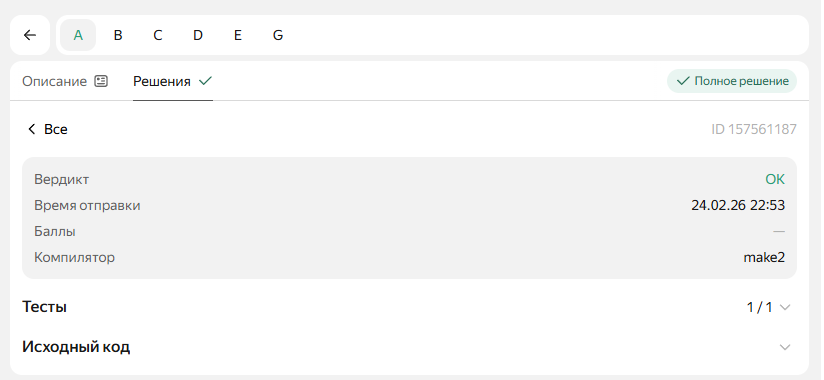


* **StochasticGradientDescent**: ID 157561312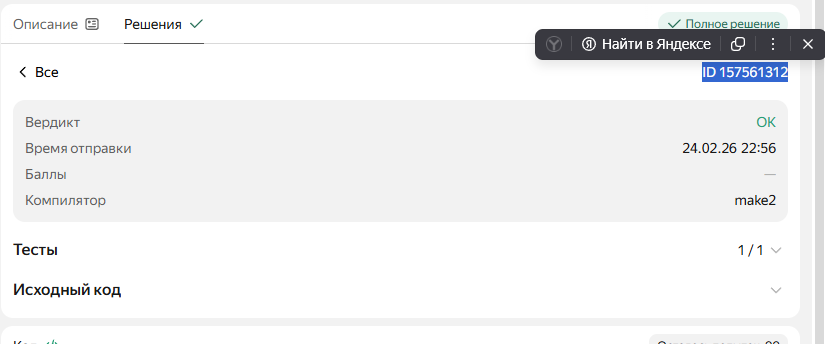


* **SAGDescent**: ID 157561350
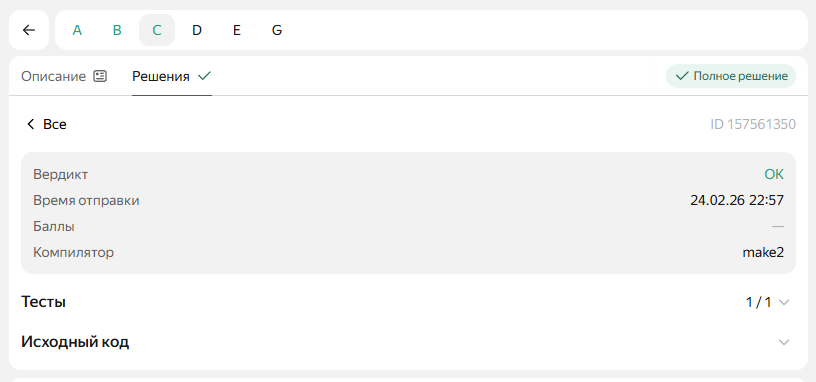


* **MomentumDescent**: ID 157561397
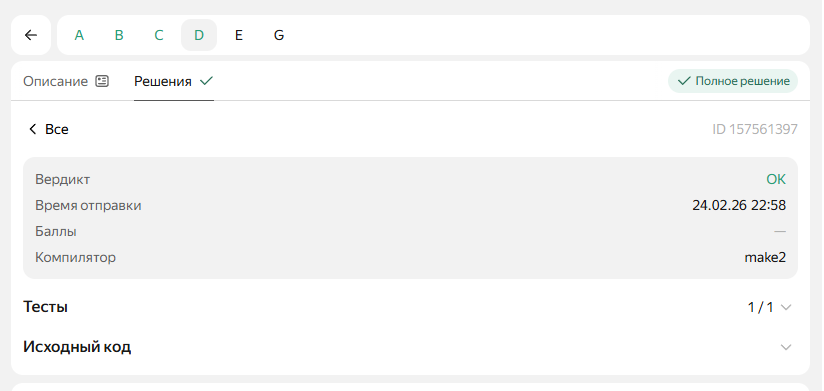

* **Adam**: ID 157561429

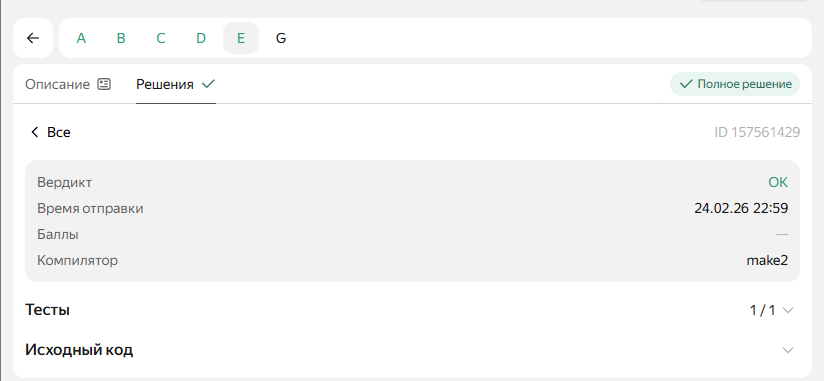


* **LinearRegression**: ID 157561476

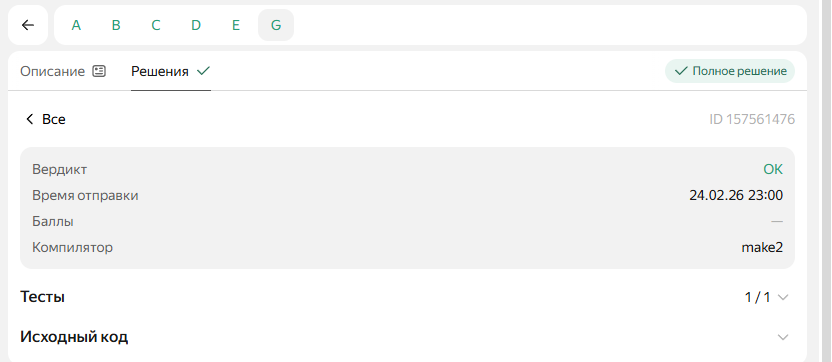

## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [1]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

/content/interfaces.py:50: SyntaxWarning: invalid escape sequence '\h'
  returns: np.ndarray, вектор \hat{y}
/content/linear_regression.py:130: SyntaxWarning: invalid escape sequence '\h'
  returns: np.ndarray, вектор \hat{y}


In [3]:
data = pd.read_csv('autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [4]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75.0,150000.0,177.0,1500.0
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69.0,90000.0,93.0,3600.0
2,bmw,3er,limousine,manuell,benzin,ja,102.0,150000.0,246.0,650.0
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109.0,150000.0,140.0,2200.0
4,mazda,3_reihe,limousine,manuell,benzin,nein,105.0,150000.0,136.0,2000.0


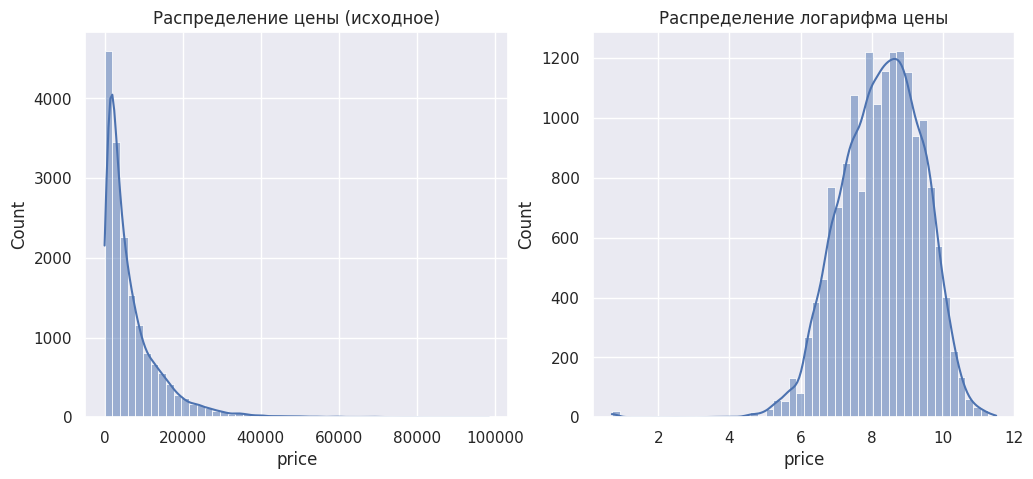

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['price'], kde=True, bins=50)
plt.title('Распределение цены (исходное)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(data['price']), kde=True, bins=50)
plt.title('Распределение логарифма цены')
plt.show()

Нужно ли заменить на логарифм?

Ответ: да, нужно, машин по низким ценам очень много, а по высоким гораздо меньше, распределение смещено вправо. Логарифмирование сделает распределение похожим на нормальное, это поможет регрессии лучше обучиться

Есть ли выборосы? - да, на лог шкале даже заметно в районе 1 есть данные, надо почистить, еще уберу сильно дорогие машины, если они вдруг есть

In [6]:
data = data[(data['price'] > 100) & (data['price'] < 150000)]

Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

Разделите признаки на категориальные, числовые и ... все остальное

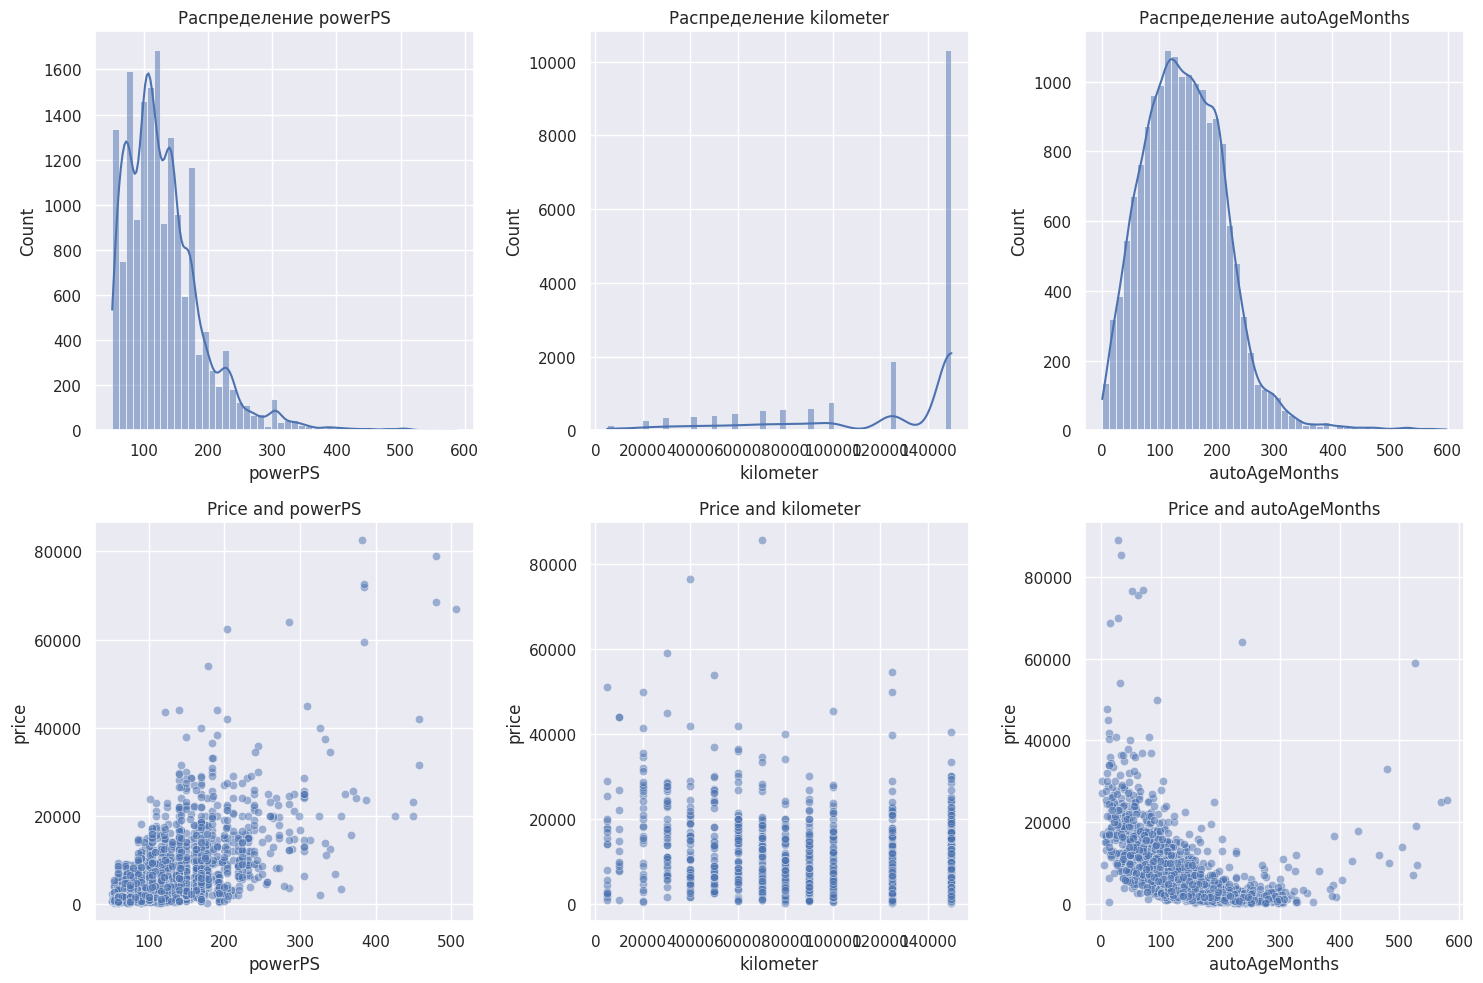

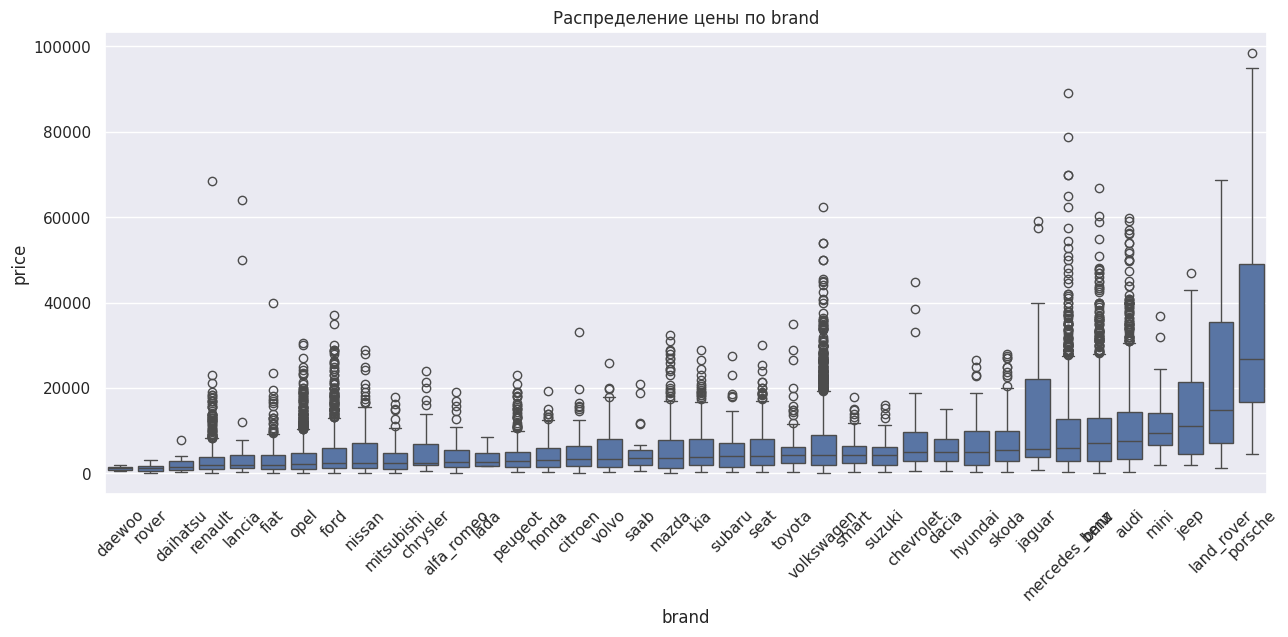

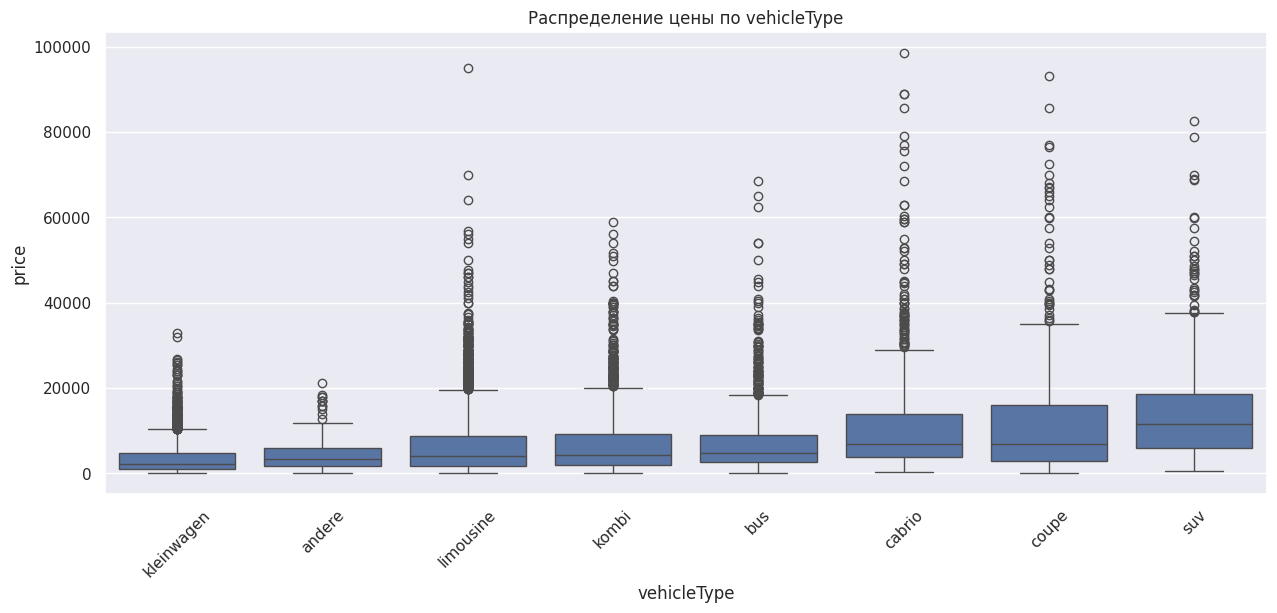

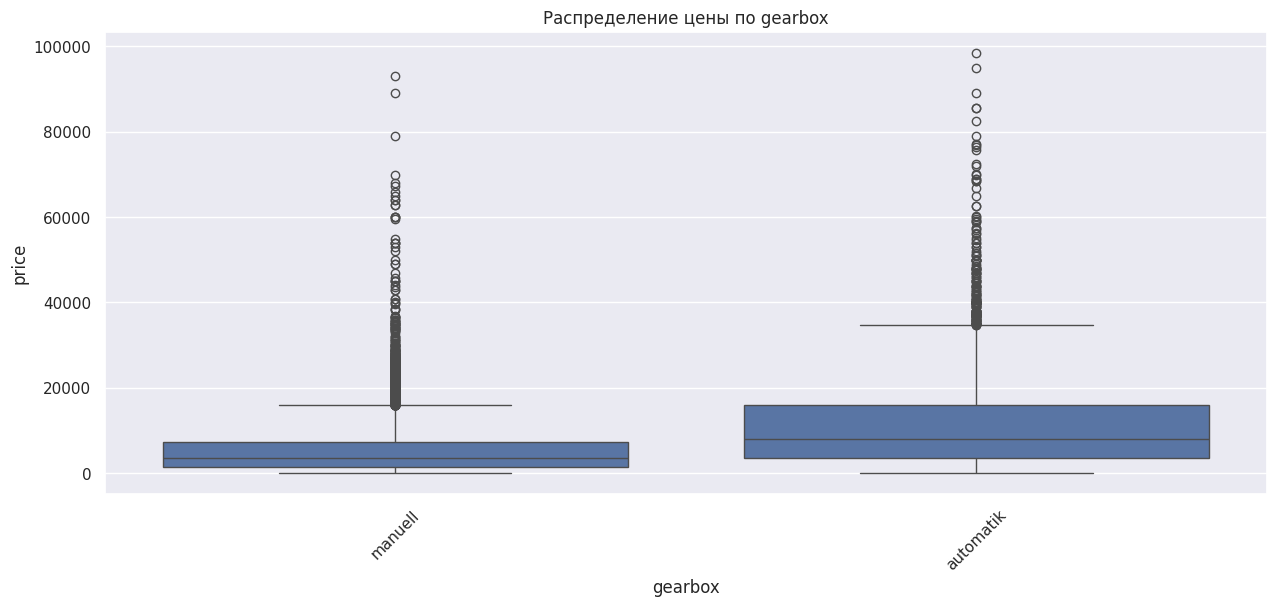

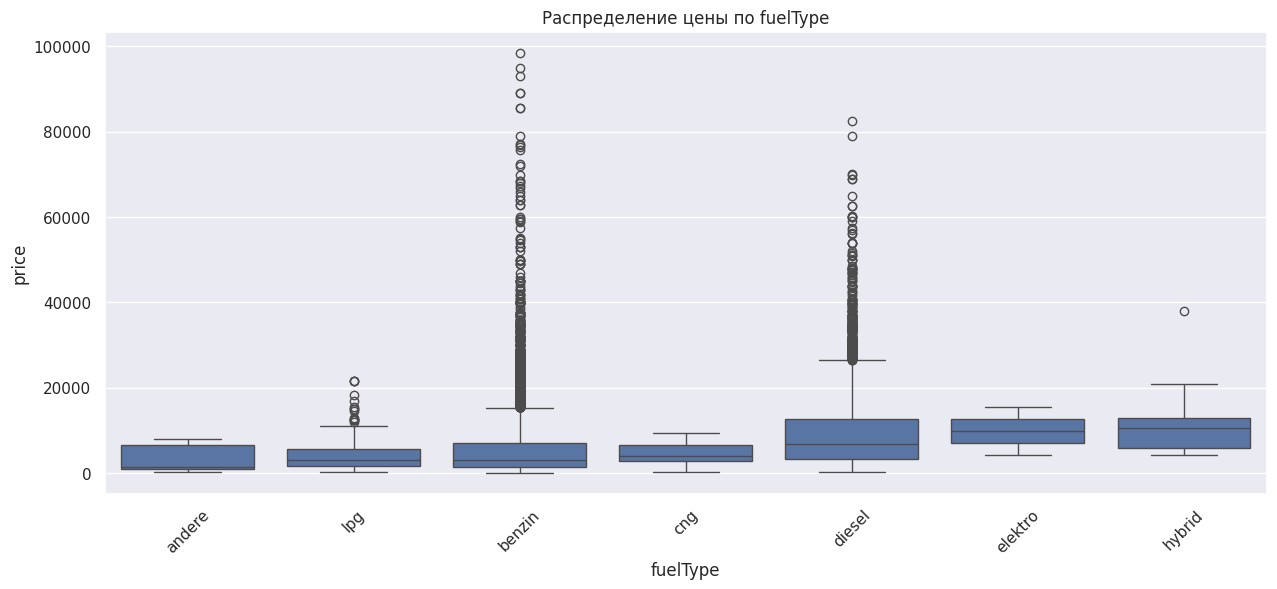

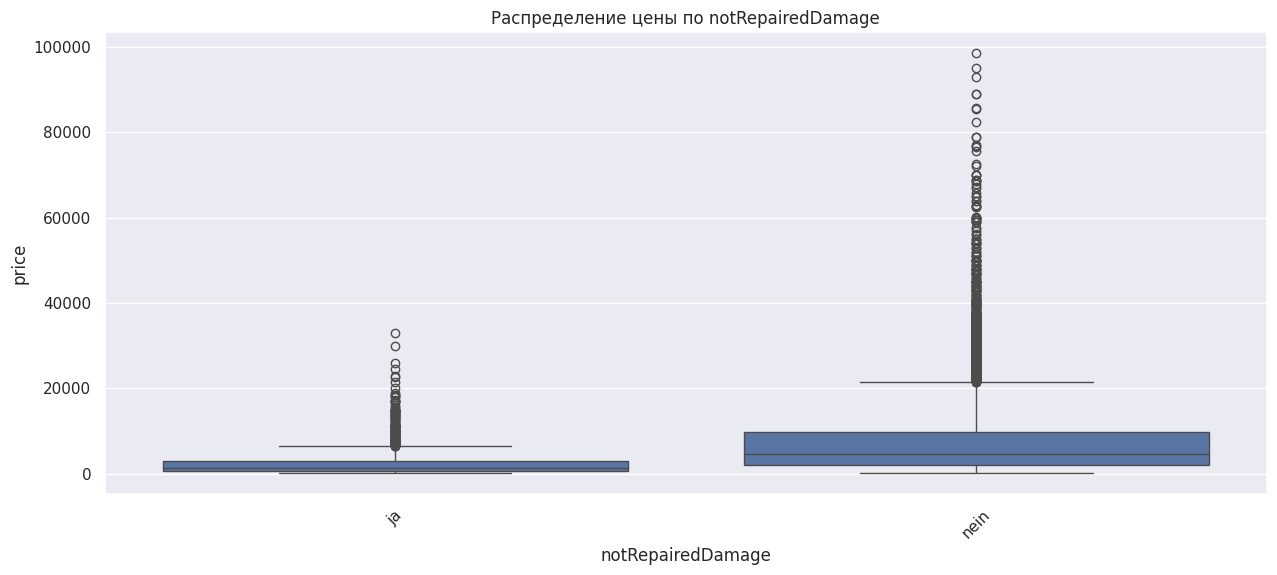

In [7]:
categorical = ['brand', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []

# YOUR CODE (EDA) HERE ٩(⁎❛ᴗ❛⁎)۶
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric):
  plt.subplot(2, 3, i + 1)
  sns.histplot(data[col], bins = 50, kde= True)
  plt.title(f'Распределение {col}')
  plt.subplot(2, 3, i + 4)
  sns.scatterplot(data=data.sample(2000), x=col, y='price', alpha=0.5)
  plt.title(f'Price and {col}')
plt.tight_layout()
plt.show()

for col in categorical:
  plt.figure(figsize=(15,6))
  order = data.groupby(col)['price'].median().sort_values().index
  sns.boxplot(data=data, x= col, y='price', order=order)
  plt.xticks(rotation=45)
  plt.title(f'Распределение цены по {col}')
  plt.show()

Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;

###Ответ:
- powerPS - на скаттер плоте видна положительная корреляция: чем выше мощность, тем выше цена
- autoAgeMonth: видная обратная зависимость, самые высокие цены у новых автомобилей, с увеличением возраста цена снижается по экспоненте
- notRepairedDamage - медианная цена у машин без повреждений выше
- gearbox - автомат увеличвает цену машины
- brand и vehickeType - бренды премиум сегмента и некторые типы кузова стоят замтено (ожидаемо) дороже

самые важные для модели - powerPS, autoAgeMonths, notRepairedDamage и brand

Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;

###Ответ:
- Логарифмирование цены
- One hot encoding для категориальныъ признаков, т к у них нет естественного порядка
- StandardScaler для вещественных признаков т к линейная регрессия и град спуск чувствительны к разным масштабам признаков

In [8]:
data = data[(data['powerPS'] > 20) & (data['powerPS'] < 600)] #оставлю 600 потому что
#если снизить, то потеряем в точности для премиального сегмента или спорткаров
data = data[data['autoAgeMonths'] < 360] #оставляем машины не старше 30 лет, старше 30 лет в германии в каую-то категрию особую уходят, для модели это не хайп

Добавляем в данные единичную колонку `bias`, чтобы не делать отдельные параметр $b$ для свободного члена модели.

In [9]:
data['bias'] = 1
other = ['bias']

X = data[categorical + numeric + other]
y = np.log1p(data['price'])

Теперь вам необходимо разбить данные на обучающую, тестовую и валидационную выборки.

In [10]:
# YOUR CODE HERE ┌(ಠ_ಠ)┘
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state= 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 13323
Val size: 1665
Test size: 1666


А также сделаем базовую обработку данных, а именно:
* Применим `OneHotEncoding` к категориальным признакам
* Стандартизуем численные признаки с помощью `StandardScaler`
* Остальные признаки трогать не будем, т.к. с ними непонятно что делать

> А почему мы сначала делим данные, а только потом применяем обработку данных? Энкодеры и скейлеры используют информацию о данных: если сделать fit на всем датасете до split, это будет утечка: статистики из val/test попадут в обучение.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

X_train = column_transformer.fit_transform(X_train)
X_val = column_transformer.transform(X_val)
X_test = column_transformer.transform(X_test)

In [12]:
#на всякий случай переведц в нампай сразу
import scipy
if scipy.sparse.issparse(X_train):
    X_train = X_train.toarray()
    X_val = X_val.toarray()
    X_test = X_test.toarray()
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

## Задание 5. Сравнение методов градиентного спуска (1.5 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (0.75 балла)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [13]:
# YOUR CODE HERE (⌐■_■)
# to find optimal lambda_
from sklearn.metrics import r2_score, mean_squared_error
lambdas = [0.001, 0.01, 0.1, 0.5, 1.0]
methods = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    MomentumDescent,
    Adam,
    SAGDescent
]
best_results = {}
for method_class in methods:
    method_name = method_class.__name__
    best_val_mse = float('inf')
    best_params = None
    for l in lambdas:
      optimizer = method_class(lr_schedule=TimeDecayLR(lambda_=l))
      model = CustomLinearRegression(optimizer=optimizer)
      model.fit(X_train, y_train)
      y_val_pred = model.predict(X_val)
      val_mse = mean_squared_error(y_val, y_val_pred)
      if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_params = {
                'lambda': l,
                'model': model,
                'iterations': len(model.loss_history) - 1
            }
    best_model = best_params['model']
    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)
    best_results[method_name] = {
        'best_lambda': best_params['lambda'],
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'iterations': best_params['iterations']
    }
    print(f"лучшая lambda: {best_params['lambda']}, test R2: {best_results[method_name]['test_r2']:.4f}")
df_results = pd.DataFrame(best_results).T
display(df_results)

лучшая lambda: 1.0, test R2: 0.7946
лучшая lambda: 0.5, test R2: 0.7877
лучшая lambda: 1.0, test R2: 0.7982
лучшая lambda: 0.5, test R2: 0.7959
лучшая lambda: 1.0, test R2: 0.7661


,best_lambda,train_mse,test_mse,test_r2,iterations
VanillaGradientDescent,1.0,0.224019,0.260373,0.794577,317.0
StochasticGradientDescent,0.5,0.231784,0.269089,0.787700,1000.0
MomentumDescent,1.0,0.214985,0.255729,0.798241,289.0
Adam,0.5,0.214397,0.258651,0.795936,145.0
SAGDescent,1.0,0.259222,0.296525,0.766055,1000.0


### Задание 5.2. Сравнение методов (0.75 балла)

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

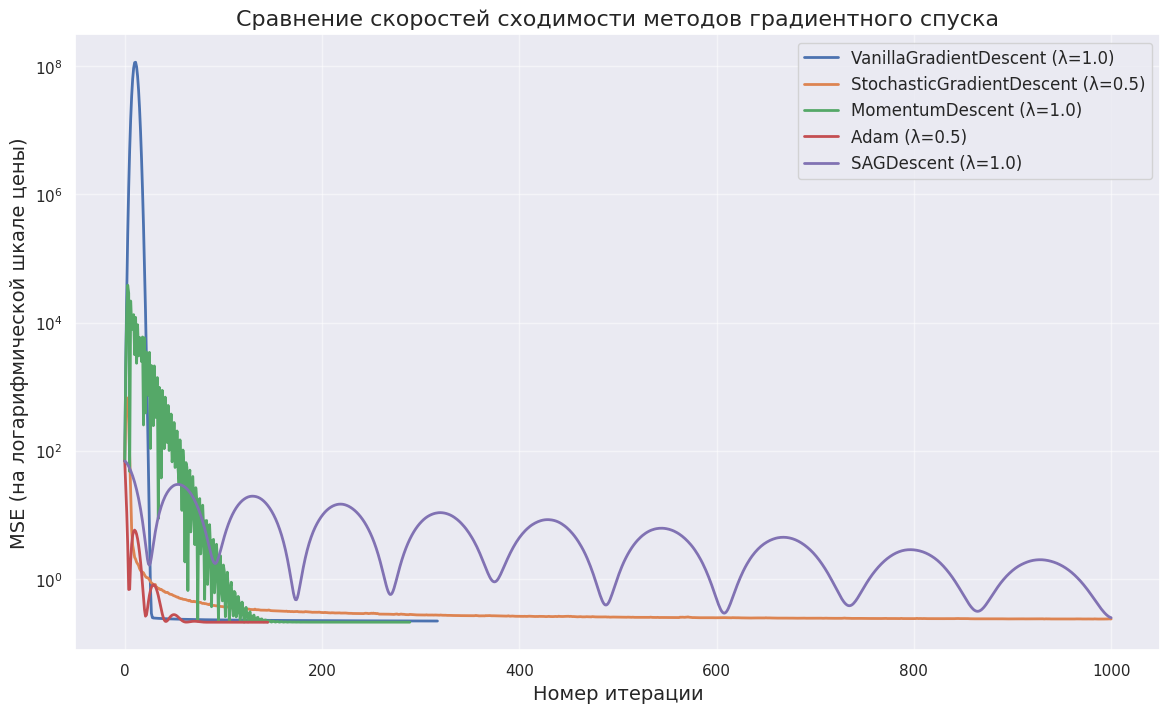

In [15]:
# YOUR CODE HERE (づ｡◕‿‿◕｡)づ
plt.figure(figsize=(14, 8))
for method_name, row in df_results.iterrows():
  best_l = row['best_lambda']
  method_class = globals()[method_name]
  optimizer = method_class(lr_schedule=TimeDecayLR(lambda_=best_l))
  model = CustomLinearRegression(optimizer=optimizer)
  model.fit(X_train, y_train)
  plt.plot(model.loss_history, label=f"{method_name} (λ={best_l})", linewidth=2)
plt.title('Сравнение скоростей сходимости методов градиентного спуска', fontsize=16)
plt.xlabel('Номер итерации', fontsize=14)
plt.ylabel('MSE (на логарифмической шкале цены)', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

На основе полученных результатов можно сделать следующие выводы - лидер по качеству и стабильности - Adam, у него нет такого сильного взлета ошибки в начале обучения, как у остальных моделей, он быстрее сходится - за 145 итераций и имеет высокое качество. SGD показал самую плавную прямую на графике - он быстро снижал ошибку, но уперся в лимит 1000 итераций. Ему не хватило точности. SAG видно что уменьшает ошибку через осцилляции, он тоже уперся в 1000 итераций, но заметна разница - тем больше итераций, тем меньше он осцилирует. Vanilla и Momentum справились тоже довольно хорошо, за 317 и 289 итераций соотвественно, но у Vanilla пик в начале существенно выше, на начальных итерациях он дает самую большую ошибку среди всех методов. В отличии от двух предыдущих методов они смогли сойтись, при этом Momentum показал самый лучший результат по мтерике $R^2$

## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска.

* Сделайте по несколько запусков (например, $k = 10$) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

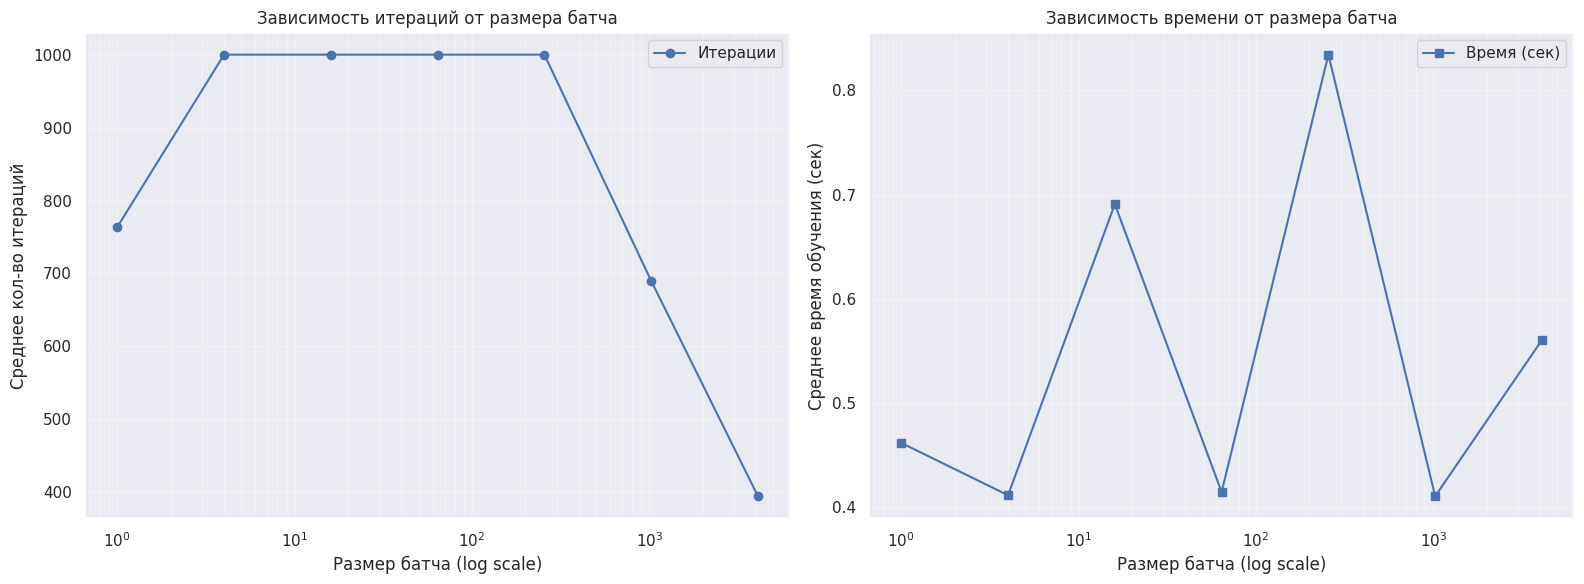

In [16]:
# YOUR CODE HERE (ง •̀_•́)ง
import time
batch_sizes = [1, 4, 16, 64, 256, 1024, 4096]
k = 10
lam = 0.5
avg_iterations = []
avg_times = []
for b_size in batch_sizes:
  iters_history = []
  time_history = []
  for _ in range(k):
    opt = StochasticGradientDescent(
        lr_schedule=TimeDecayLR(lambda_=lam),
        batch_size=b_size,
    )
    model = CustomLinearRegression(optimizer=opt)
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    iters_history.append(len(model.loss_history) - 1)
    time_history.append(end_time - start_time)
  avg_iterations.append(np.mean(iters_history))
  avg_times.append(np.mean(time_history))
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(batch_sizes, avg_iterations, marker='o', label='Итерации')
plt.xscale('log')
plt.xlabel('Размер батча (log scale)')
plt.ylabel('Среднее кол-во итераций')
plt.title('Зависимость итераций от размера батча')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(batch_sizes, avg_times, marker='s', label='Время (сек)')
plt.xscale('log')
plt.xlabel('Размер батча (log scale)')
plt.ylabel('Среднее время обучения (сек)')
plt.title('Зависимость времени от размера батча')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Выводы:**

`# your text here (ಠ.ಠ)`

Про итерации: видно, что мелкие и средние батчи не могут дать нужной точности или требуют много итераций, для батчей 4, 16, 64, 256 модель просто отрабатывала до максимально возможного количества итераций. На батче 1024 наблюдается заметное улучшение - модель достигала нужного уровня tolerance за +-680 итераций, но лучший результат у батча 4096, градиент стал сходится еще  быстрее, за +- 400 итераций. Вывод - для больших данных как в этом задании лучше использоваь батчи побольше для максимальной точности

Про время: затраты по времени минимальны для любого количества батчей, но заметно чередование - минимумы при 4, 64 и 1024 батчах и пики при 1, 16, 256, 4096, но видно, что после пика на 256 батчах идет снижение затрат по времени на 4096, значит алгоритм ускоряется при достаточно болбших размерах батчей, но наблюдается преимущество в 0.15 секунды на 1024 батчах отгносительно 4096

В итоге для больших данных большие батчи оказываются эффективнее

## Задание 7. Регуляризация (0.5 балла)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация – это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать $L_2$-регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Допишите класс `linear_regression.L2Regularization`, следуя интерфейсу и докуметации.

Используя регуляризованный лосс в эксприментах, найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравните для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего должно получиться 5 графиков).

Посмотрите на получившиеся результаты. Какие можно сделать выводы, как регуляризация влияет на сходимость? Как изменилось качество на обучающей выборке? На тестовой? Чем вы можете объяснить это?

,Best Lambda,Best Mu,R2 No Reg,R2 With Reg,MSE No Reg,MSE With Reg,Train R2 Reg,Iters Reg
Method,,,,,,,,
VanillaGradientDescent,1.0,0.0001,0.794577,0.794550,0.260373,0.260407,0.815869,316
StochasticGradientDescent,0.5,0.0100,0.787700,0.785868,0.269089,0.271412,0.807287,1000
MomentumDescent,1.0,0.0001,0.798241,0.798275,0.255729,0.255686,0.823298,280
Adam,1.0,0.0001,0.795936,0.795810,0.258651,0.258811,0.823427,101
SAGDescent,1.0,0.0100,0.766055,0.735233,0.296525,0.335591,0.756763,1000


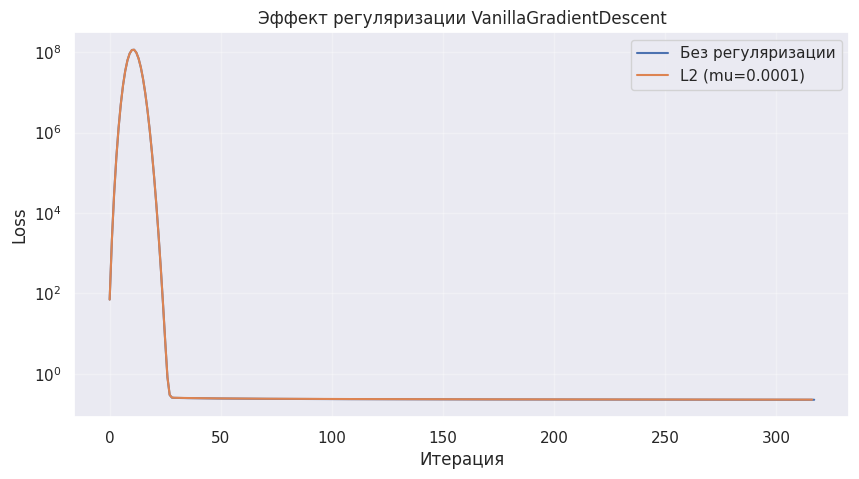

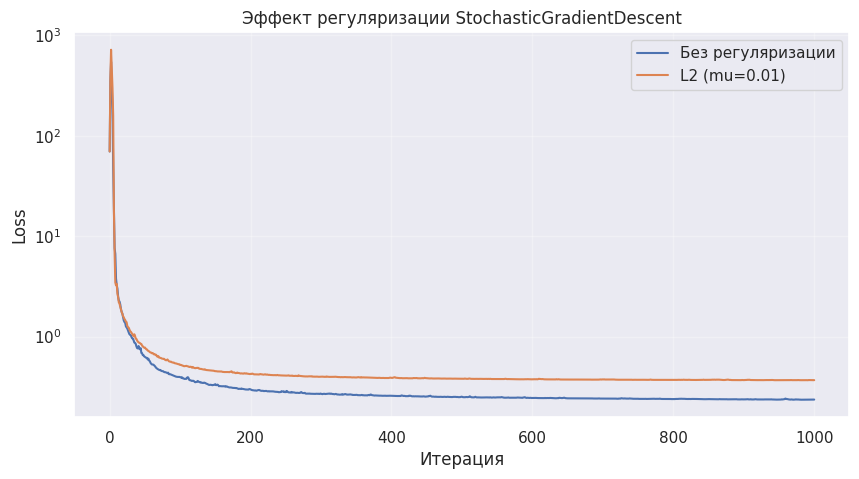

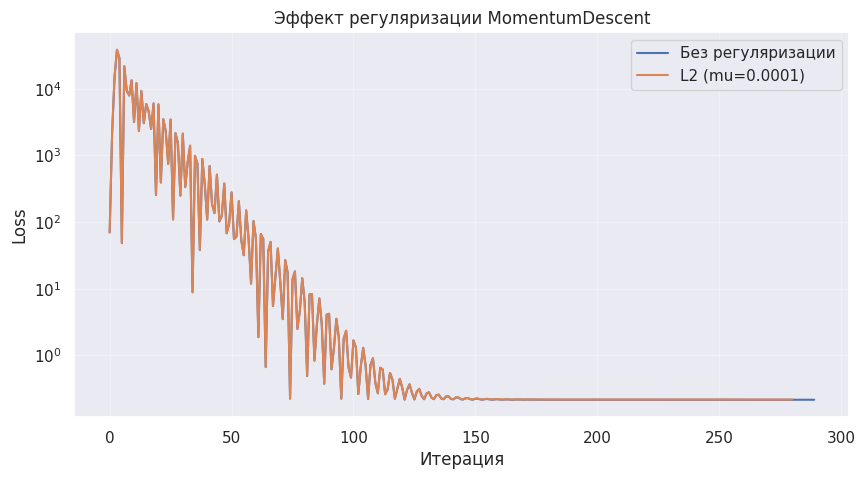

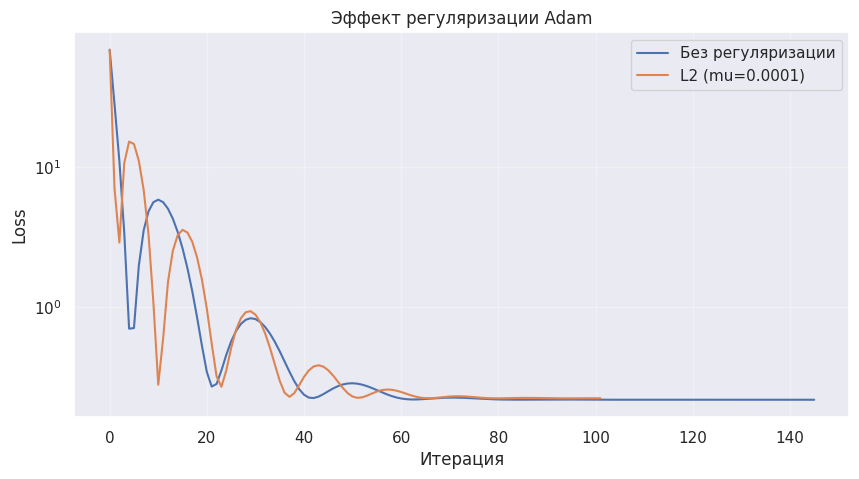

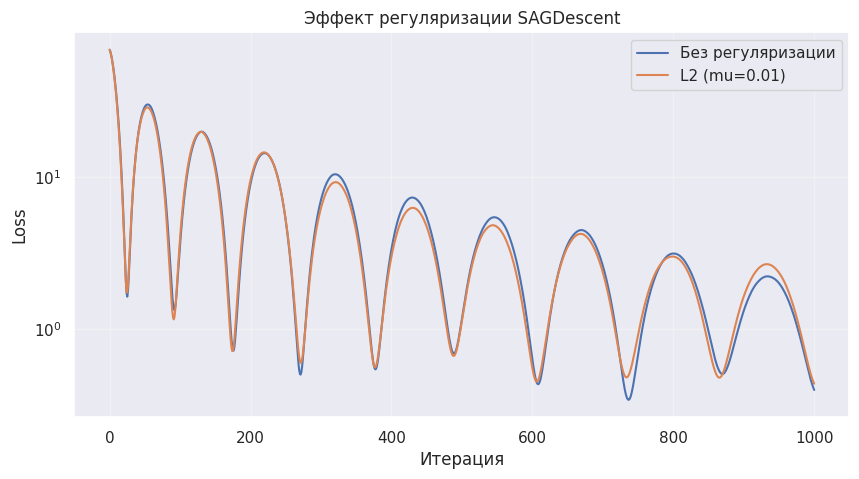

In [17]:
# YOUR CODE HERE (✿◠‿◠)
import numpy as np
import pandas as pd  #пишу все импорты заново, т к пришлось рестартить среду выполнения
import matplotlib.pyplot as plt
from linear_regression import MSELoss, CustomLinearRegression, L2Regularization
from descents import (
    TimeDecayLR,
    VanillaGradientDescent,
    StochasticGradientDescent,
    MomentumDescent,
    Adam,
    SAGDescent
)
from sklearn.metrics import r2_score, mean_squared_error
lambdas = [0.01, 0.1, 0.5, 1.0]
mus = [0.0001, 0.01, 1.0]
methods = [VanillaGradientDescent, StochasticGradientDescent, MomentumDescent, Adam, SAGDescent]
reg_final_results = []
best_reg_models = {}
for MethodClass in methods:
  method_name = MethodClass.__name__
  best_mu = None
  best_lambda = None
  best_r2 = -float('inf')
  best_model = None
  for l in lambdas:
    for m in mus:
      l2_loss = L2Regularization(core_loss=MSELoss(), mu_rate=m)
      optimizer = MethodClass(lr_schedule=TimeDecayLR(lambda_=l))
      model = CustomLinearRegression(optimizer=optimizer, loss_function=l2_loss)
      model.fit(X_train, y_train)

      r2_val = r2_score(y_val, model.predict(X_val))
      if r2_val > best_r2:
        best_r2 = r2_val
        best_mu = m
        best_lambda = l
        best_model = model
  best_reg_models[method_name] = best_model
  y_test_pred = best_model.predict(X_test)
  y_train_pred = best_model.predict(X_train)
  old_r2 = df_results.loc[method_name, 'test_r2']
  old_mse = df_results.loc[method_name, 'test_mse']
  reg_final_results.append({
      'Method': method_name,
      'Best Lambda': best_lambda,
      'Best Mu': best_mu,
      'R2 No Reg': old_r2,
      'R2 With Reg': r2_score(y_test, y_test_pred),
      'MSE No Reg': old_mse,
      'MSE With Reg': mean_squared_error(y_test, y_test_pred),
      'Train R2 Reg': r2_score(y_train, y_train_pred),
      'Iters Reg': len(best_model.loss_history) - 1
  })
df_compare = pd.DataFrame(reg_final_results).set_index('Method')
display(df_compare)
for m_name in [m.__name__ for m in methods]:
  plt.figure(figsize=(10, 5))
  old_l = df_results.loc[m_name, 'best_lambda']
  m_cls = globals()[m_name]
  o_nr = m_cls(lr_schedule=TimeDecayLR(lambda_=old_l))

  m_nr = CustomLinearRegression(optimizer=o_nr, loss_function=MSELoss())
  m_nr.fit(X_train, y_train)

  plt.plot(m_nr.loss_history, label='Без регуляризации')
  plt.plot(best_reg_models[m_name].loss_history, label=f'L2 (mu={df_compare.loc[m_name, "Best Mu"]})')
  plt.title(f'Эффект регуляризации {m_name}')
  plt.xlabel('Итерация')
  plt.ylabel('Loss')
  plt.yscale('log')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()


**Вывод:**

`# your text here (ಠ.ಠ)`

Для моделей Vanilla, Momentum и Adam победила минимальная регляризация 0.0001. Влияние на итоговое качество $R^2$ оказалось незначительным. Это говорит, что на таком объеме данных (190к строк) и умеренном количестве признаков модель не переобучается - данных достаточно, чтобы веса не становилимь слишком большими

Вывод по SGD и SAG: для них была выбрана бОльшая регулярищация (0.01). Однако это привело к небольшому снижению $R^2$ на тесте. Это можно объяснить тем, что что стохастические методы сами по себе обладают эффектом регуляризации из-за шума в батчах, и дополнительный штраф оказался лишним

Adam с регуляризацией сошелся за 101 итерацию (против 145 без неё). Это отличный результат — L2 помогла алгоритму быстрее убрать лишнее и прийти к стабильному решению

**Как регуляризация влияет на сходимость?**

Регуляризация делает целевую функцию более гладкой, для адам это заметно больше всего, там существенно сократилось количество итераций до сходимости

**Как изменилось качество на обучающей выборке?**

На обучающей выборке качество после добавления регуляризации выше, чем на тестовой. После добавления регуляризации оно практически не изменилось

**Как изменилось качество на тестовой выборке?**

Качество на тесте осталось +- на том же уровне, только для SGD оно стало заметно хуже

**Чем вы можете объяснить это?**

Мы видим что разрыв между трейн и тест небольшой, значит модель хорошо обобщвет данные. Регуляризация должна была заметнее убрать этот разрыв, но у нас модели и так довольно устойчивые (эффект Bias-Variance Tradeoff)

## Задание 8. Альтернативные функции потерь (1 балл)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **LogCosh** и **HuberLoss**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
   \frac{1}{2} (a_i - y_i)^2, & \text{если } |a_i - y_i| < \delta, \\
   \delta \cdot |a_i - y_i| - \frac{1}{2} \delta^2, & \text{если } |a_i - y_i| \geq \delta,
\end{cases}
$$

Самостоятельно продифференцируйте данные функции потерь чтобы найти их градиенты _(требуется показать не только результат, но и промежуточные вычисления)_:

**Решение:**

`# your solution here (ಠ.ಠ)`

Буду опираться на результаты, полученные ранее в задании 1 ну и дополню их под это задание:

Пусть $z_i = a_i - y_i = \langle x_i, w \rangle - y_i$. Тогда:

#### 1. LogCosh Loss
Функция: $L(y_i, a_i) = \log(\cosh(z_i))$

По правилу производной сложной функции $(\log(u))' = \frac{u'}{u}$ и $(\cosh(z))' = \sinh(z)$:
$$\frac{\partial L}{\partial a_i} = \frac{1}{\cosh(z_i)} \cdot \sinh(z_i) = \tanh(z_i)$$

В матричном виде градиент по весам $w$:
$$\nabla_w Q(w) = \frac{1}{\ell} X^T \tanh(Xw - y)$$

#### 2. Huber Loss
Функция:
$$L_{\delta}(z_i) = \begin{cases} \frac{1}{2}z_i^2, & |z_i| \le \delta \\ \delta(|z_i| - \frac{1}{2}\delta), & |z_i| > \delta \end{cases}$$

Дифференцируем по $a_i$:
1. Если $|z_i| \le \delta$: $\frac{\partial L}{\partial a_i} = z_i = a_i - y_i$
2. Если $|z_i| > \delta$: $\frac{\partial L}{\partial a_i} = \delta \cdot \text{sign}(z_i)$

В векторном виде:
$$
\frac{\partial L}{\partial a_i} =
\begin{cases}
a_i - y_i, & \text{если } |a_i - y_i| \le \delta \\
\delta \cdot \text{sgn}(a_i - y_i), & \text{если } |a_i - y_i| > \delta
\end{cases}
$$

$$\nabla_w Q(w) = \frac{1}{\ell} X^T \frac{\partial L}{\partial a}$$




Программно реализуйте функции потерь и их градиенты для LogCosh и HuberLoss в файле `linear_regression.py`. После этого обучите все пять методов градиентного спуска (без регуляризации) с этими лоссами аналогично заданию 5 и сравните качество с результатами из задания 5, где использовался MSE.

Имплементировать эти функции потерь необходимо при помощи наследования от `linear_regression.LossFunction` и имплементирования всех абстрактных методов. Аналитическое решение для этих функций выводить и имплементировать не требуется.



In [19]:
from linear_regression import LogCoshLoss, HuberLoss
alternative_losses = {
    'LogCosh': LogCoshLoss(),
    'Huber': HuberLoss(delta=1.0)
}
best_lambdas = {
    'VanillaGradientDescent': 1.0,
    'StochasticGradientDescent': 0.5,
    'MomentumDescent': 1.0,
    'Adam': 1.0,
    'SAGDescent': 1.0
}
alt_results_list = []
for loss_name, loss_fn in alternative_losses.items():
  for MethodClass in methods:
    method_name = MethodClass.__name__
    l = best_lambdas[method_name]
    opt = MethodClass(lr_schedule=TimeDecayLR(lambda_=l))
    model = CustomLinearRegression(optimizer=opt, loss_function=loss_fn)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    old_r2 = df_results.loc[method_name, 'test_r2']
    alt_results_list.append({
            'Loss Function': loss_name,
            'Method': method_name,
            'Test R2': test_r2,
            'Test MSE': test_mse,
            'Diff with MSE Loss (R2)': test_r2 - old_r2
        })
df_alt_compare = pd.DataFrame(alt_results_list).sort_values(by='Test R2', ascending=False)
display(df_alt_compare)
print("\nСредний R2 по всем методам:")
print(df_alt_compare.groupby('Loss Function')['Test R2'].mean())

,Loss Function,Method,Test R2,Test MSE,Diff with MSE Loss (R2)
7,Huber,MomentumDescent,0.796052,0.258503,-0.002188
2,LogCosh,MomentumDescent,0.795825,0.258791,-0.002415
8,Huber,Adam,0.793060,0.262296,-0.002876
3,LogCosh,Adam,0.792840,0.262575,-0.003096
5,Huber,VanillaGradientDescent,0.782434,0.275765,-0.012144
0,LogCosh,VanillaGradientDescent,0.780017,0.278827,-0.014560
6,Huber,StochasticGradientDescent,0.779946,0.278918,-0.007754
1,LogCosh,StochasticGradientDescent,0.778300,0.281004,-0.009400
9,Huber,SAGDescent,-0.086707,1.377399,-0.852762
4,LogCosh,SAGDescent,-0.133665,1.436918,-0.899720



Средний R2 по всем методам:
Loss Function
Huber      0.612957
LogCosh    0.602664
Name: Test R2, dtype: float64


**Выводы:**
Видна эффективность фугнкций Huber и LogCosh для всех методов кроме SAG. Huber оказался чуть лучше LogCosh для большинства методов т к Huber позволяет гибко переключаться между квадратичной и линейной ошибкой. Данные функции потерь на самом деле довольно устйочивые, испольщование таких лоссов оправдано на сырых данных, но я предобработал их, убрав выбросы, а целевую переменную логарифмировал, поэтмоу эффект не столь заметен. Методы с инерцией Momentum и Adam лучше всего справились с альтернативными лоссами, показав самую точную сходимость

### Кулинарно-социализационный бонус. (0.5 балла)

Как мы знаем, в феврале зима уже не объяснение, а обстоятельство непреодолимой силы - и лучший способ спорить с ней это поделиться теплом с друзьями и близкими. Выберите рецепт, который соответствует вашему настроению, приготовьте выбранное блюдо и угостите хотя бы одного человека им. Кратко опишите ваши впечатления, прикрепите рецепт и фотографии блюда и довольного гостя.

В середине выполнения домашки появился вайб приготовить пиццу, на этом фото мой братишка кушает мой шедевр (слева на фотке). Я часто что-то готовлю, но в этот раз мне очень нужно было переключится с домашки по МО и чет поделать, поэтому удовольствия от готовки я получил больше, чем обычно (тогда хоть грелась духовка, а не моя ...). А вот и рецепт этой пиццы - Пшеничная мука 800 г
Сухие дрожжи 24 г
Соль 2 чайные ложки
Вода 400 мл
Оливковое масло 3 столовая ложка
Томатный соус 300 г
Салями 300 г
Сыр 100 г
Помидоры 1 штука
Маслины 250 г (можно еще чет добавить по вайбу)
1) Приготовить тесто: смешать муку, соль, дрожжи, теплую кипяченую воду и оливковое масло. Месить тесто необходимо около 5 минут, затем нужно дать ему подняться в течение получаса
2) Раскатать тесто в круг и поставить в разогретую до 200-220 градусов духовку на 5 минут
3) Помидоры и маслины тонко нарезать
4) Достать из духовки корж, намазать соус, выложить начинку в следующей последовательности: сыр, салями или пепперони, помидоры, маслины и немного тертого сыра сверху. По желанию можно еще поперчить. Отправить пиццу в духовку еще на 5-10 минут  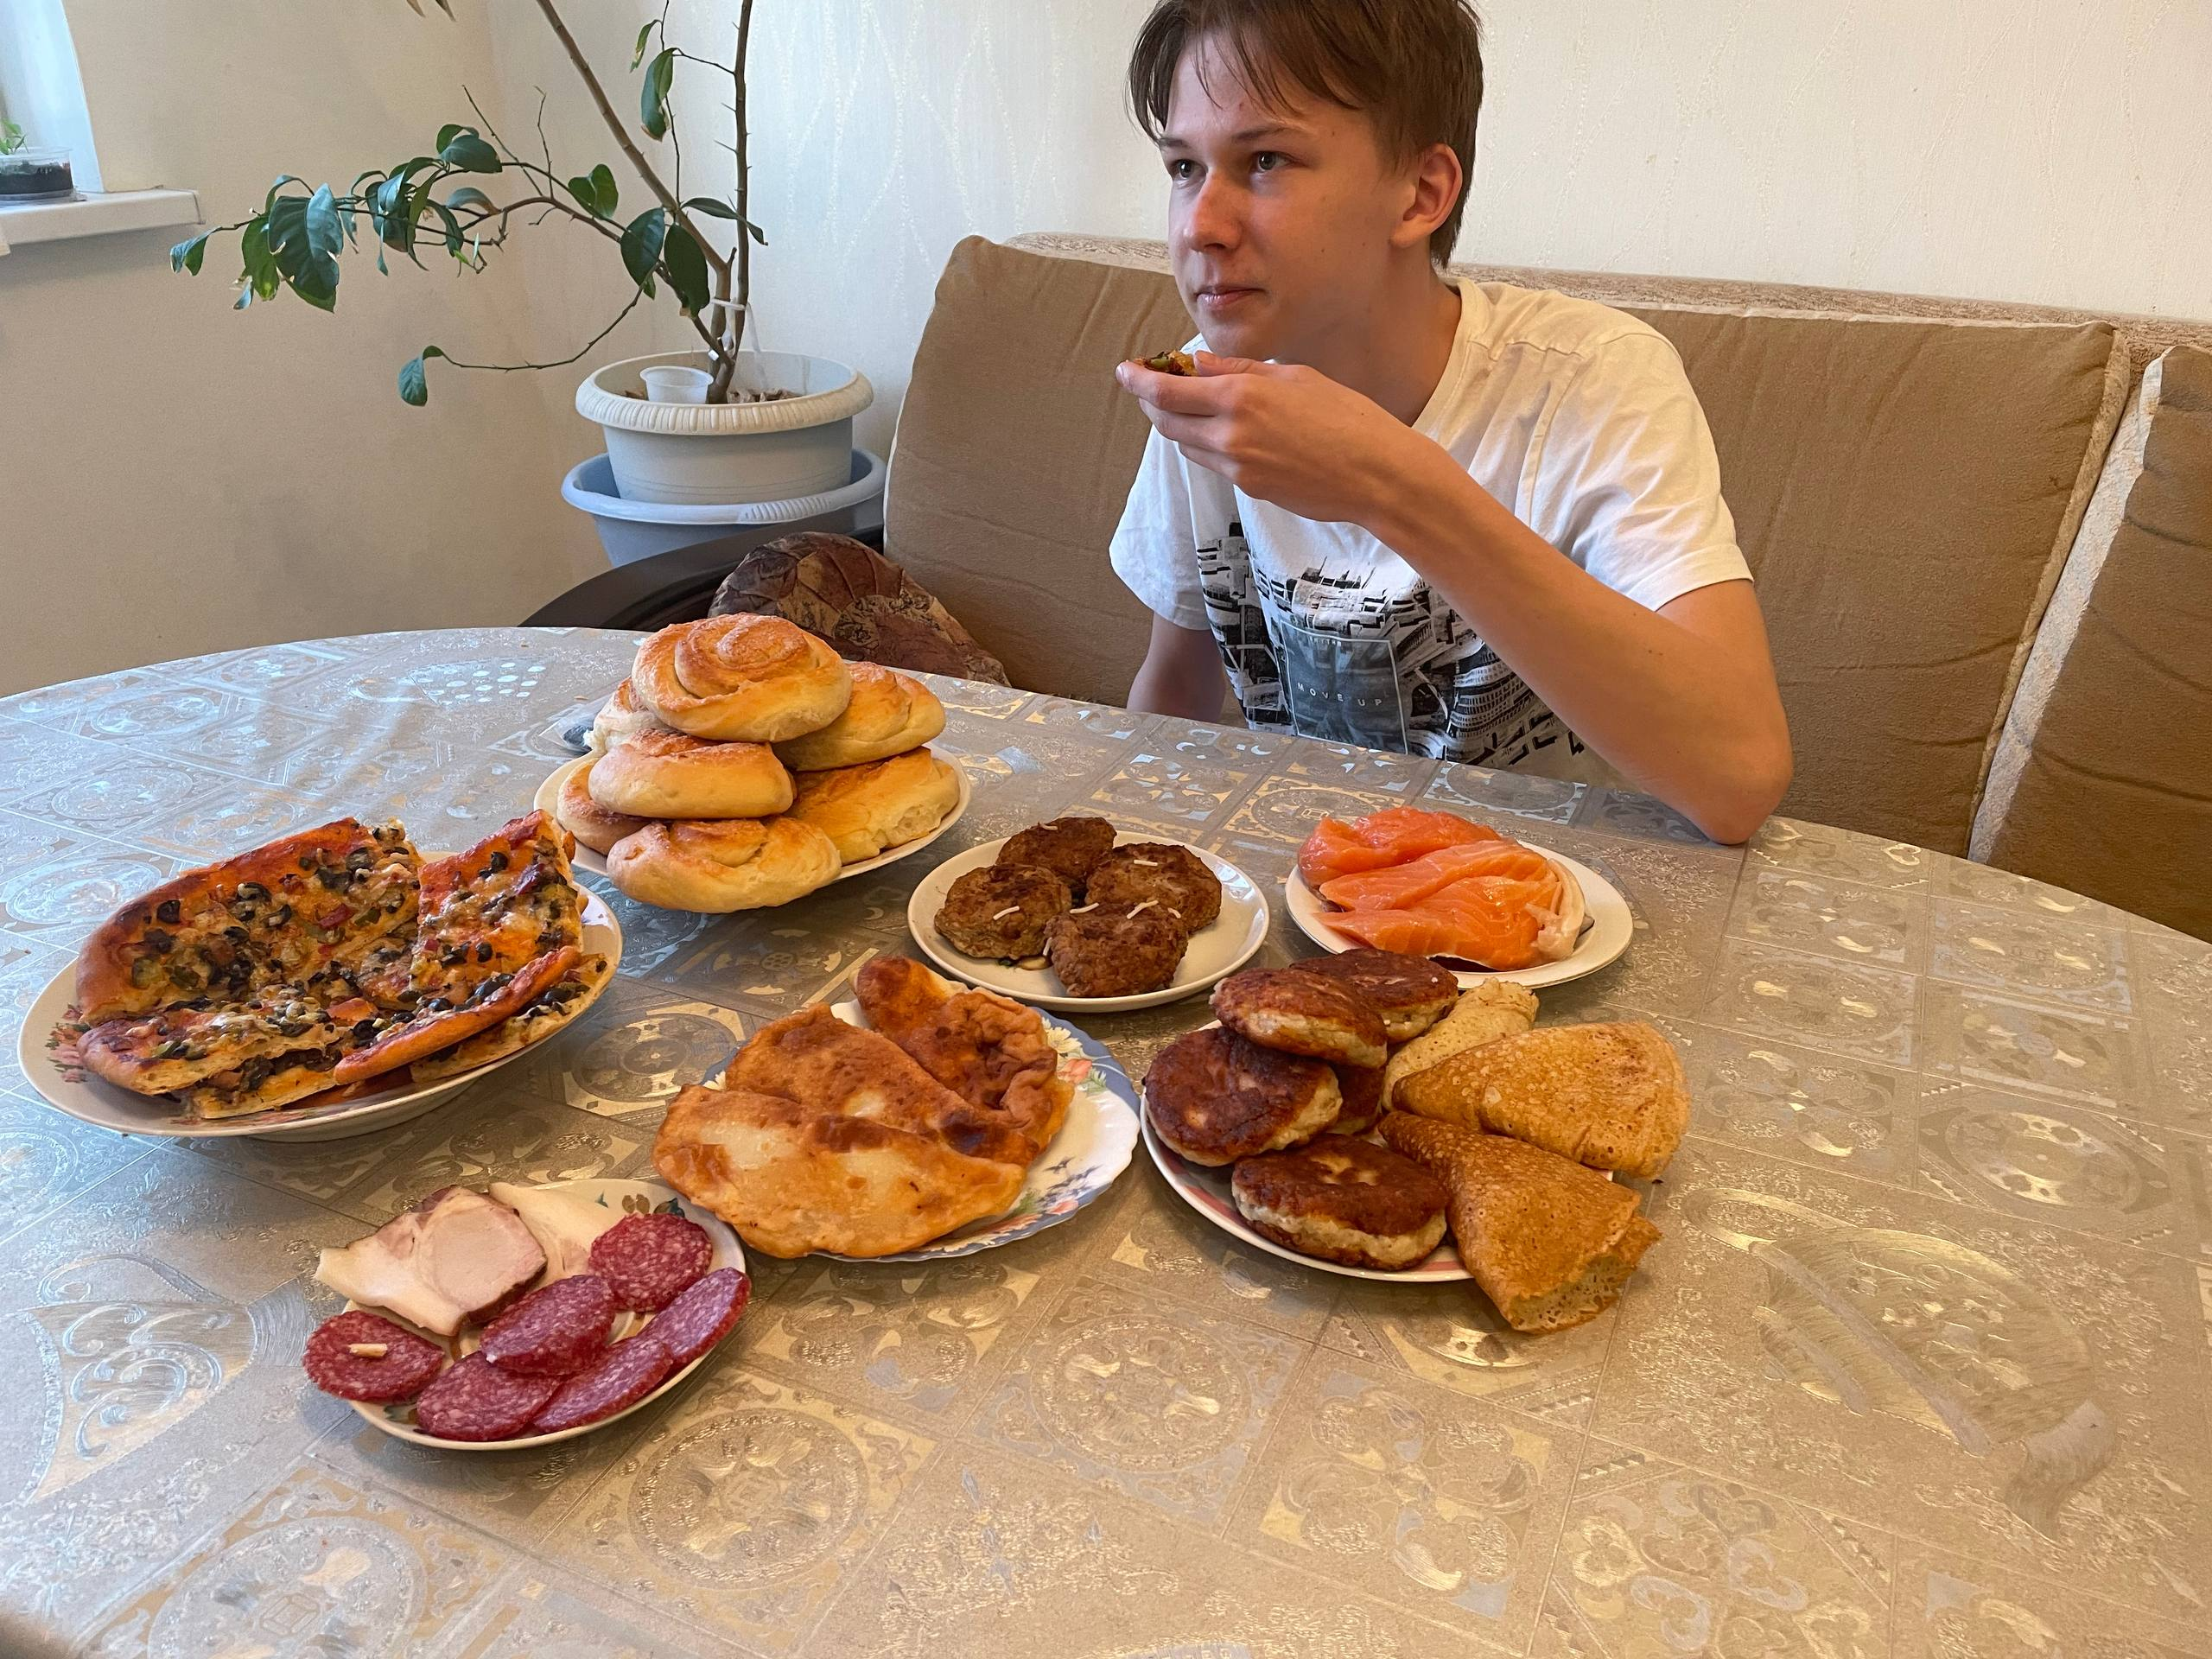